In [36]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import math
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB
from genetic_algorithm import GA_functions as GA
from genetic_algorithm import curve_fitting as cf
from scipy import integrate
import torch
import warnings
warnings.filterwarnings("ignore")

## Description

To fit the experimental data of the HuHF-PIX dissolved in deuterium oxide, a model consisting of the ferratin cage monomer and a ferratin cage dimer was used. The atomic coordinates of the ferritin cage were retrieved from the PDB file, and dimers were generated by duplicating the cage and placing the copy at a separation distance, determined by a fitting parameter, away from the original structure. Additional fitting parameters include the proportion of dimers in the solution, the incoherent background, and the scale parameter. 

## Functions used to extract protein structure

In [37]:
def relative_coordinates(volume):
    '''This function is used to center any set of coordinates at the origin'''
    rel_x = volume[:,0] - np.mean(volume[:,0])
    rel_y = volume[:,1] - np.mean(volume[:,1])
    rel_z = volume[:,2] - np.mean(volume[:,2])
    relative_volume = np.hstack((rel_x.reshape(-1,1), rel_y.reshape(-1,1), rel_z.reshape(-1,1), volume[:,-1].reshape(-1,1)))
    return relative_volume


def extract_data(file_path):
    """
    Extract numeric data from a .dat file.
    Skips comment lines starting with # or non-numeric rows.
    Returns numpy array and pandas DataFrame.
    """

    data = []

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()

            # Skip empty lines and comments
            if not line or line.startswith("#"):
                continue

            try:
                # Split by whitespace and convert to float
                row = [float(value) for value in line.split()]
                data.append(row)
            except ValueError:
                # Skip lines that can't be converted to float
                continue

    if not data:
        raise ValueError("No numeric data found in file.")

    data_array = np.array(data)

    # Create DataFrame with generic column names
    columns = [f"col_{i+1}" for i in range(data_array.shape[1])]
    df = pd.DataFrame(data_array, columns=columns)

    return data_array, df

## Functions used to fit the experimental data

In [38]:
def set_limits(parameters):
    '''This function converts the input parameters which range from 0 to 1 into the correct values
    used to create the sheet model. This is because the inputs and outputs of the genetic algoritm range from 0 to 1.
    '''
    upper = 200
    lower = 122
    d = parameters[0]*(upper - lower) + lower # distance between ferritin cages in the dimer 
    upper = 1
    lower = 0
    prop = parameters[1]*(upper - lower) + lower # proportion of dimers in the solution
    upper = 1e-1
    lower = 1e-3 
    background = parameters[2]*(upper - lower) + lower # incoherent background 
    upper = 1e-3
    lower = 1e-5
    scale = parameters[3]*(upper - lower) + lower # scale parameter 
    return d, prop, background, scale


def create_lattice_coords(d, prop, background, scale):
    '''This function creates the sheet model using the specified parameters and simulates its scattering curve
    Inputs:
    - d: separation distance between the proteins 
    - length: length of the sheet 
    - width: width of the sheet 
    - height: height of the sheet
    - distortion: random distortion of the protein in the height of the sheet 
    - monomer_proportion: proportion of unassembled monomers in the solution 
    - scale: arbitraty parameter used to scale the intensity curve 
    Outputs:
    - the lattice coordinate array with the x,y,z, coordinates of each lattice and the amount of rotation 
      around each axis.
    '''
    lattice_coordinates = np.array([[0, 0, 0],[d, 0, 0]])
    return lattice_coordinates

def invariant(data):
    '''Calculates the invariant'''
    q = data[:,0]
    I = data[:,1]
    invariant = integrate.simpson(q**2*I, q)
    return invariant

def objective_function(d, prop, background, scale):
    '''This function creates the sheet model using the specified parameters and simulates its scattering curve
    Inputs:
    - d: separation distance between the proteins 
    - length: length of the sheet 
    - width: width of the sheet 
    - height: height of the sheet
    - distortion: random distortion of the protein in the height of the sheet 
    - monomer_proportion: proportion of unassembled monomers in the solution 
    - scale: arbitraty parameter used to scale the intensity curve 
    Outputs:
    - A 2D array with q and scattering intensity of the specified model 
    '''
    coordinates = Read_PDB.load_pdb_SANS('../Data/PDB/ferritin_pdb.pdb')
    lattice_coords = create_lattice_coords(d, prop, background, scale)
    n_samples = 10000000
    simulator = pairwise_method.scattering_simulator(n_samples)
    histogram_bins = 10000
    q = np.geomspace(0.012, 0.5, 3000)
    Iq_monomer = pd.read_csv("../Data/ferritin/simulated_ferratin_cage_highq.csv").values[:,1] 
    Iq_dimer = simulator.simulate_scattering_curve_fast_lattice(coordinates, lattice_coords, histogram_bins, q).cpu()
    Inv_monomer = invariant(np.hstack((q.reshape(-1,1), Iq_monomer.reshape(-1,1))))
    Inv_dimer = invariant(np.hstack((q.reshape(-1,1), Iq_dimer.reshape(-1,1))))
    I_q_all = (Iq_dimer/Inv_dimer*(1-prop) + (prop)/Inv_monomer*Iq_monomer/2)*scale + background
    return np.hstack((q.reshape(-1,1), I_q_all.reshape(-1,1)))


def objective_function_multiple(d, prop, background, scale):
    '''This function creates the sheet model using the specified parameters and simulates its scattering curve
    It is similar to the above function (objective_function), but the output scattering curve is simulated 10 times
    for better accuracy. 
    Inputs:
    - d: separation distance between the proteins 
    - length: length of the sheet 
    - width: width of the sheet 
    - height: height of the sheet
    - distortion: random distortion of the protein in the height of the sheet 
    - monomer_proportion: proportion of unassembled monomers in the solution 
    - scale: arbitraty parameter used to scale the intensity curve 
    Outputs:
    - A 2D array with q and scattering intensity of the specified model 
    '''
    coordinates = Read_PDB.load_pdb_SANS('../Data/PDB/ferritin_pdb.pdb') 
    lattice_coords = create_lattice_coords(d, prop, background, scale)
    n_samples = 10000000
    simulator = pairwise_method.scattering_simulator(n_samples)
    simulator.sample_building_block(coordinates)
    simulator.sample_lattice_coordinates(lattice_coords)
    simulator.calculate_structure_coordinates()

    histogram_bins = 10000
    q = torch.tensor(geomspace(0.012, 0.5, 3000))
    I_q = simulator.simulate_multiple_scattering_curves_lattice_coords(coordinates, lattice_coords, histogram_bins, q)
    I_q = I_q.cpu()
    Iq_dimer = torch.mean(I_q[:,1:], dim=1)
    Iq_monomer = pd.read_csv("../Data/ferritin/simulated_ferratin_cage_highq.csv").values[:,1] 
    Inv_monomer = invariant(np.hstack((q.reshape(-1,1), Iq_monomer.reshape(-1,1))))
    Inv_dimer = invariant(np.hstack((q.reshape(-1,1), Iq_dimer.reshape(-1,1))))
    I_q_all = (Iq_dimer/Inv_dimer*(1-prop) + (prop)/Inv_monomer*Iq_monomer/2)*scale + background
    return torch.cat((q.view(-1,1), I_q_all.view(-1,1)), dim=1)


def convert_data(data, model):
    '''This function bins the model data so that it has the same number of data points as the experimental data
    inputs:
    - data: the experimental data with q and intensity as the two colums in the 2D array
    - model: the simulated data with q and intensity as the two columns in the 2D array
    output:
    - new_model_data: the binned model data with q and I as the two columns in the 2D array'''
    model_x = model[:,0]
    model_y = model[:,1]
    index = np.linspace(0, len(model_x)-1, len(model_x)) 
    model_q_new = []
    model_I_new = []
    for i in range(len(data)):
        data_q = data[i,0]
        array = np.abs(model_x - data_q)
        array = np.hstack((array.reshape(-1,1), index.reshape(-1,1)))
        array = array[np.argsort(array[:, 0])]
        loc = int(array[0,1])
        model_q_new.append(model_x[loc])
        model_I_new.append(model_y[loc])
    q = np.array(model_q_new).reshape(-1,1)
    I = np.array(model_I_new).reshape(-1,1)
    new_model_data = np.hstack((q, I))
    return new_model_data


def evaluate_obj_func(parameters, exp_data):
    '''This function evaluates the objective function and obtains a score for each set of input parameters
    inputs:
    - parameters: a 1D array of length 7 with each value corresponding to a structural parameter of the sheet model. These values range
    from 0 to 1 and are obtain from the genetic algorithm
    exp_data: the experimental data of the sheet structure
    outputs:
    - error: The score between the scattering curve of the model and the experimental data'''
    d, prop, background, scale = set_limits(parameters)
    sim_data = objective_function(d, prop, background, scale)
    sim_data = convert_data(exp_data, sim_data)
    plt.rcParams.update({'font.size': 22})
    #fig, ax = plt.subplots(figsize=(7,7))
    plt.ylabel('Intensity (arb. unit)')
    plt.xlabel('q ($\\AA^{-1}$)')
    plt.xscale('log')
    plt.yscale('log')
    plt.plot(sim_data[:,0], sim_data[:,1])
    plt.plot(exp_data[:,0], exp_data[:,1], linewidth=3, color ='k')
    error = np.mean(np.abs(np.log10(np.abs(exp_data[:,1])) - np.log10(np.abs(sim_data[:,1]))))
    return -error

def evaluate_obj_func_loop(x, exp_data):
    '''This function evaluates the objective function in a loop and obtains a score for each set of input parameters
    inputs:
    - x: a 2D array of columns 7 and as many rows with each column corresponding to a structural parameter of the sheet model. Each row represents
    a different candidate. All values range from 0 to 1 and are obtain from the genetic algorithm
    outputs:
    - y: an array of scores between the scattering curve of the model and the experimental data'''
    for i in range(x.shape[0]): # This is a loop that runs the test function for each row of an array
        y_row = evaluate_obj_func(x[i,:], exp_data)
        if i == 0:
            y = y_row
        else:
            y = np.vstack((y, y_row))
    return y

def run_optimization(exp_data, batch_size, mutation_rate, iterations):
    '''This function runs the genetic optimizer
    inputs:
    - exp_data: experimental data of the sample
    - batch_size: number of samples in each iteration
    - mutation_rate: controls exploration vs exploitation of the GA
    - iterations: number of iterations to run
    outputs:
    - alg.best_solution(): the best solution found in the optimization 
    - alg.max_fitness_lst: the history of the best scores at each iteration 
    '''
    x = np.random.rand(batch_size, 4)
    y = evaluate_obj_func_loop(x, exp_data)
    alg = GA.genetic_algorithm(batch_size, mutation_rate)
    for i in range(iterations):
        x = alg.run(x,y)
        y = evaluate_obj_func_loop(x, exp_data)
    return alg.best_solution(), alg.max_fitness_lst

## Importing the atomic coordinates of the ferritin cage protein

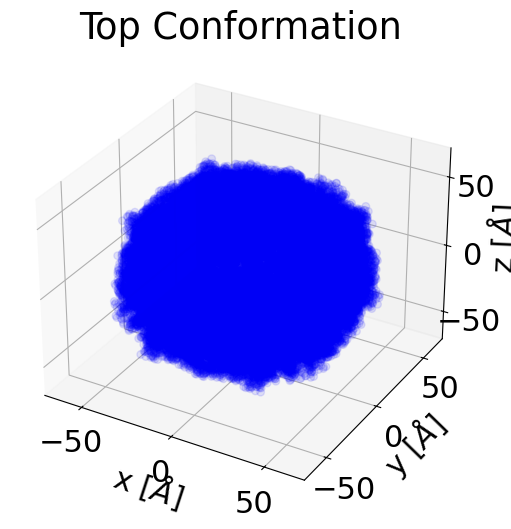

In [39]:
coordinates = Read_PDB.load_pdb_SANS('../Data/PDB/ferritin_pdb.pdb') 
coordinates = relative_coordinates(coordinates)
# Plotting
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')
ax.scatter(coordinates[:,0],coordinates[:,1],coordinates[:,2], color = 'blue', alpha = 0.1, s = 30)
ax.set_xlabel('x [$\\AA$]')
ax.set_ylabel('y [$\\AA$]')
ax.set_zlabel('z [$\\AA$]')
ax.set_title('Top Conformation')
building_block = coordinates

## Importing and plotting the experimental data

Text(0.5, 0, 'q ($\\AA^{-1}$)')

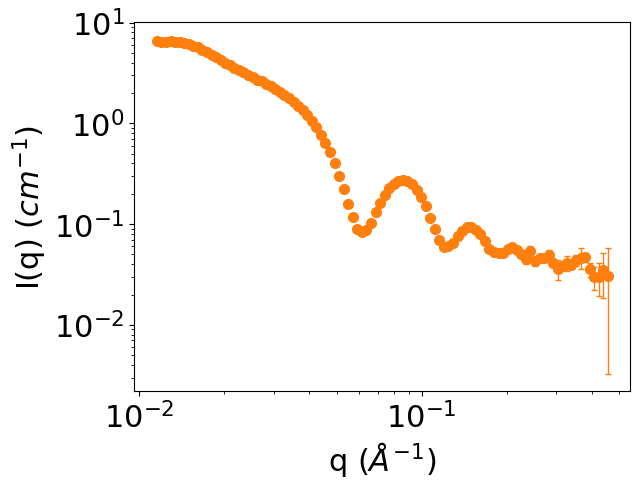

In [40]:
exp_data = extract_data('../Data/ferritin/2c_I(q)_dissolved_PIX_ornl.txt')[0][0:]

plt.errorbar(
    exp_data[:,0], exp_data[:,1],
    yerr=exp_data[:,2],
    fmt='o',
    markersize=7,
    capsize=2,
    elinewidth=1,
    color = 'C1',
    ecolor='C1',
    zorder=0
)



plt.yscale('log')
plt.xscale('log')
plt.ylabel('I(q) ($cm^{-1}$)')
plt.xlabel('q ($\\AA^{-1}$)')

## Run the Fitting Algorithm 
The fitting algorithm is a genetic algorithm. The batch_size, mutation_rate, and iterations are optimization parameters. 

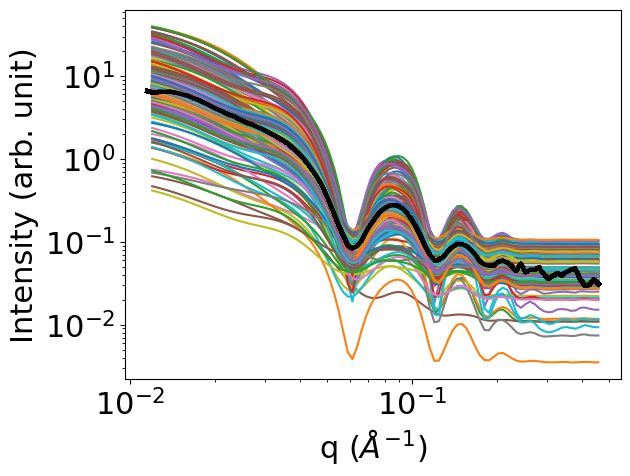

In [41]:
batch_size = 30
mutation_rate = 0.15
iterations = 20
best_solution, max_fitness_lst = run_optimization(exp_data, batch_size, mutation_rate, iterations)

## Check the best score at each iteration (closer to 0 is a better fit)

Text(0, 0.5, 'Score')

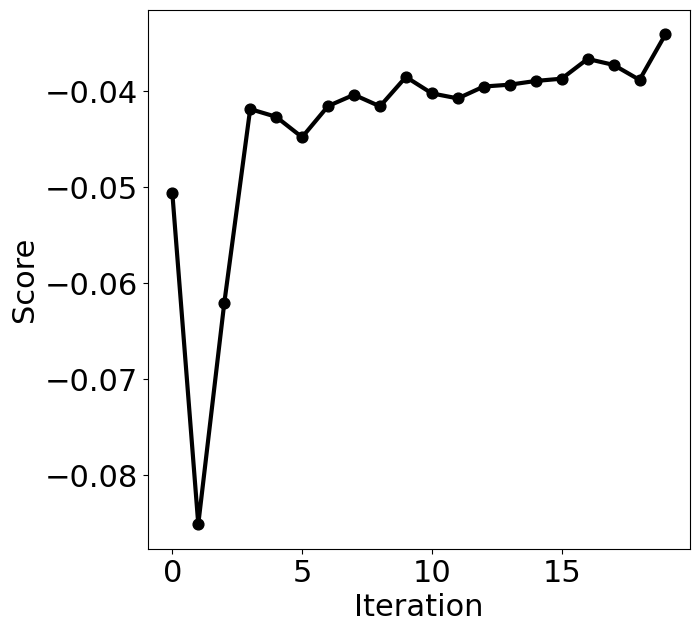

In [43]:
fig, ax = plt.subplots(figsize=(7,7))
itr = np.arange(0,iterations)
plt.plot(itr, max_fitness_lst, linewidth = 3, color='k')
plt.scatter(itr, max_fitness_lst, s = 60, color ='k')
plt.xlabel('Iteration')
plt.ylabel('Score')
#plt.savefig('../Images/RhuA/Sheets_Score_5.png', dpi=600, bbox_inches="tight")

## Extract the best fit parameters and plot the data

In [44]:
values = set_limits(best_solution)
print('d: ', values[0])
print('Prop Monomer: ',values[1])
print('background: ',values[2])
print('scale: ',values[3])


d:  170.204
Prop Monomer:  0.786
background:  0.040303000000000005
scale:  0.00073666


In [45]:
#values = [165.29, 0.647, 0.043, 0.0004347]
best_fit = objective_function(values[0], values[1], values[2], values[3])
#best_fit = objective_function_multiple(values[0], values[1], values[2])
#best_fit_mean = torch.mean(best_fit[:,1:], dim=1)

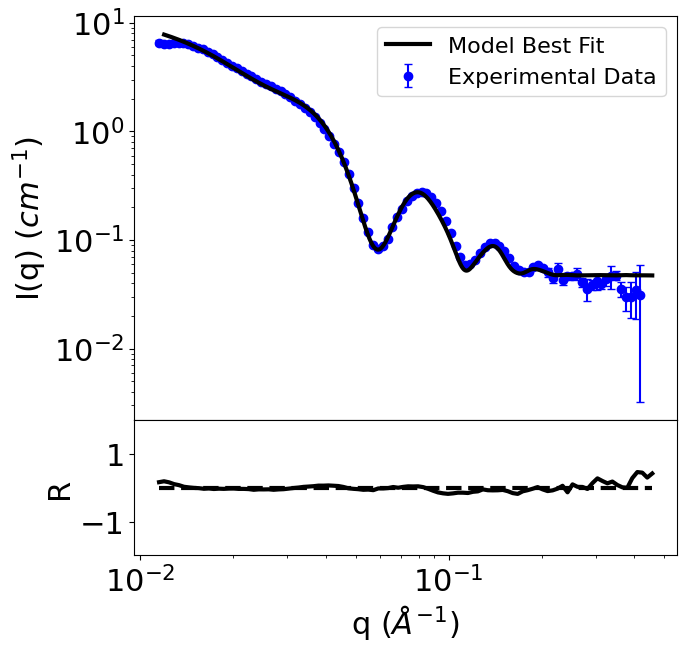

In [ ]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7), ncols = 1, nrows=2,  gridspec_kw={'height_ratios': [3, 1]})
#q = np.geomspace(0.004, 0.2, 200)
q = best_fit[:,0]
ax[0].errorbar(exp_data[:,0], exp_data[:,1], yerr=exp_data[:,2], label = 'Experimental Data', color = 'blue', capsize=3, fmt='o', zorder=0)
ax[0].plot(best_fit[:,0], best_fit[:,1], color = 'k', linewidth=3, label = 'Model Best Fit')
#ax[0].errorbar(q, simulated_data, color='k', linewidth=3, label = 'Model Best Fit')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('I(q) ($cm^{-1}$)')
ax[0].set_xticks([])
#ax[0].grid()

ax[0].legend(fontsize=16)
plt.subplots_adjust(hspace=0)

model_data = cf.convert_data(exp_data, np.hstack((q.reshape(-1,1), best_fit[:,1].reshape(-1,1))))

model_residual = (np.log(model_data[:,1]/exp_data[:,1]))

ax[1].plot(exp_data[:,0], model_residual, color ='k', linewidth = 3)
ax[1].set_ylim([-2,2])
ax[1].set_yticks([-1,1])
ax[1].set_xscale('log')
ax[1].set_ylabel('R')
ax[1].hlines(0, np.min(exp_data[:,0]), np.max(exp_data[:,0]), color='k', linewidth=3, linestyle='--')
ax[1].set_xlabel('q ($\\AA^{-1}$)')

#plt.savefig('../Images/Ferritin_dimer_fit.png', dpi=600, bbox_inches="tight")



In [ ]:
# np.savetxt(
#     "../Data/ferritin/simulated_ferratin_dimer_monomer_fit.txt",
#     best_fit,
#     header="q  I(q)",
#     comments="",
#     fmt="%.6e"
# )